# FastRP Python Demo

This notebook demonstrates how to use the high-performance Python bindings of the `fastrp` library.

In [1]:
# !pip install numpy scipy networkx matplotlib scikit-learn

In [2]:
import numpy as np
import networkx as nx
import scipy.sparse as sp
import fastrp

print("fastrp successfully imported!")

fastrp successfully imported!


In [3]:
# Load Zachary's Karate Club graph, a standard social network benchmark
G = nx.karate_club_graph()
n_nodes = G.number_of_nodes()
print(f"Graph loaded with {n_nodes} nodes and {G.number_of_edges()} edges.")

Graph loaded with 34 nodes and 78 edges.


In [4]:
nx.adjacency_matrix(G).toarray()

array([[0, 4, 5, ..., 2, 0, 0],
       [4, 0, 6, ..., 0, 0, 0],
       [5, 6, 0, ..., 0, 2, 0],
       ...,
       [2, 0, 0, ..., 0, 4, 4],
       [0, 0, 2, ..., 4, 0, 5],
       [0, 0, 0, ..., 4, 5, 0]], shape=(34, 34))

In [5]:
# 1. Adjacency List format: list of list of (neighbor_id, weight)
adj_list = [ [(neighbor, data.get('weight', 1.0)) for neighbor, data in G[node].items()]
    for node in G.nodes()
           ]

# Instantiate FastRP and fit
model = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_adj = model.fit_transform(adj_list)
print("Embeddings shape (adjacency list):", embeddings_adj.shape)

Embeddings shape (adjacency list): (34, 16)


In [6]:
# 2. Dense Adjacency Matrix format
adj_matrix = nx.to_numpy_array(G)

model_dense = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_dense = model_dense.fit_transform(adj_matrix)
print("Embeddings shape (dense):", embeddings_dense.shape)

# Verify outputs match
assert np.allclose(embeddings_adj, embeddings_dense, atol=1e-5)
print("Success: Adjacency list and Dense embeddings are identical!")

Embeddings shape (dense): (34, 16)
Success: Adjacency list and Dense embeddings are identical!


In [7]:
# 3. Scipy CSR Sparse Matrix format
adj_sparse = nx.to_scipy_sparse_array(G, format="csr")

model_csr = fastrp.FastRP(dim=16, weights=[0.0, 1.0, 1.0], seed=42, undirected=True)
embeddings_csr = model_csr.fit_transform(adj_sparse)
print("Embeddings shape (CSR sparse):", embeddings_csr.shape)

# Verify outputs match
assert np.allclose(embeddings_adj, embeddings_csr, atol=1e-5)
print("Success: CSR embeddings match others!")

Embeddings shape (CSR sparse): (34, 16)
Success: CSR embeddings match others!


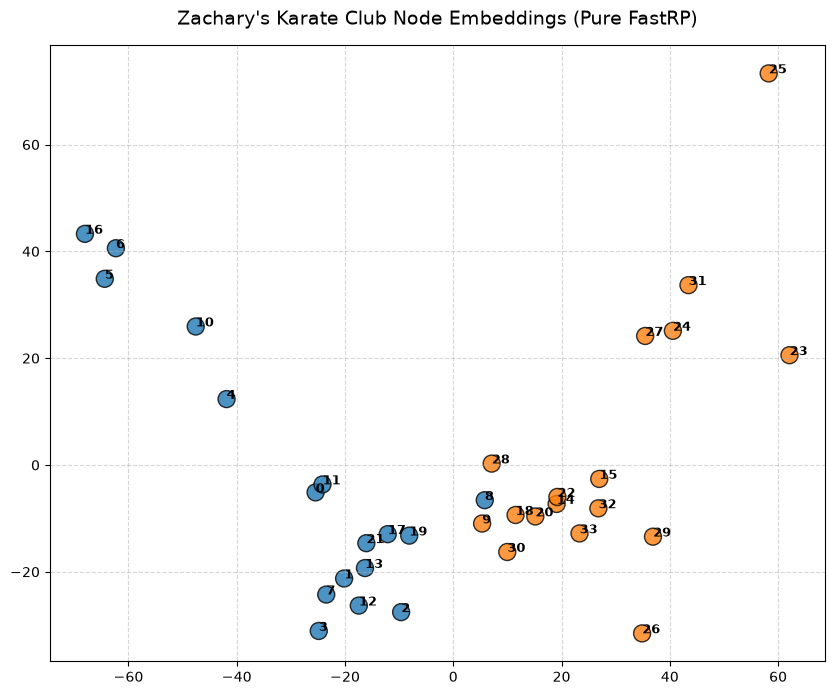

In [8]:
# Visualizing 2D PCA Embeddings of Pure Topological FastRP
try:
    import matplotlib.pyplot as plt
    from sklearn.decomposition import PCA
    
    pca = PCA(n_components=2)
    emb_2d = pca.fit_transform(embeddings_dense)
    
    # Node colors based on club faction
    colors = ["#1f77b4" if G.nodes[node]["club"] == "Mr. Hi" else "#ff7f0e" for node in G.nodes()]
    
    plt.figure(figsize=(10, 8))
    plt.scatter(emb_2d[:, 0], emb_2d[:, 1], c=colors, s=150, edgecolors="black", alpha=0.8)
    
    # Add labels
    for node in G.nodes():
        plt.text(emb_2d[node, 0] + 0.02, emb_2d[node, 1] + 0.02, str(node), fontsize=9, weight="bold")
        
    plt.title("Zachary's Karate Club Node Embeddings (Pure FastRP)", fontsize=14, pad=15)
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()
except ImportError:
    print("Please install scikit-learn and matplotlib to view the visual embeddings plot.")

## 4. Node Property-Influenced FastRP Extension

FastRP allows incorporating node property/feature vectors $X \in \mathbb{R}^{V \times m}$ into the initial projection matrix $H_0$:

$$H_0 = H_{\text{rand}} + \gamma \cdot (X \cdot W_{\text{feat}})$$

To demonstrate the true dual influence of **Graph Topology** vs. **Node Properties**:
- **Colors (Blue vs. Orange)** represent the topological **Graph Factions** ("Mr. Hi" vs. "Officer").
- **Markers (Triangles `^` vs. Crosses `X`)** represent **Node Property Group A vs. Group B**, assigned **randomly** across nodes independent of graph structure.

Observe in the plots below how increasing `feature_weight` $\gamma$ shifts the embedding layout to cluster nodes sharing identical property attributes (**triangles together, crosses together**) while preserving topological proximity!

In [17]:
# 1. Randomly assign node property categories (independent of graph topology)
np.random.seed(42)
property_groups = np.random.choice([0, 1], size=n_nodes)

# Property Group 0 (Triangles): Feature profile [4.0, 3.0, 0.0, 0.0, 1.0]
# Property Group 1 (Crosses): Feature profile [0.0, 0.0, 4.0, 3.0, -1.0]
node_features = np.zeros((n_nodes, 5))
for i in range(n_nodes):
    if property_groups[i] == 0:
        node_features[i] = [4.0, 3.0, 0.0, 0.0, 1.0] + np.random.randn(5) * 0.15
    else:
        node_features[i] = [0.0, 0.0, 4.0, 3.0, -1.0] + np.random.randn(5) * 0.15

# 2. Compute FastRP embeddings with node properties
model_feat = fastrp.FastRP(
    dim=16,
    weights=[0, 1.0, 1.0],
    seed=42,
    undirected=True,
    node_features=node_features,
    feature_weight=2.0
)
embeddings_feat = model_feat.fit_transform(adj_matrix)
print("Property-influenced embeddings shape:", embeddings_feat.shape)

Property-influenced embeddings shape: (34, 16)


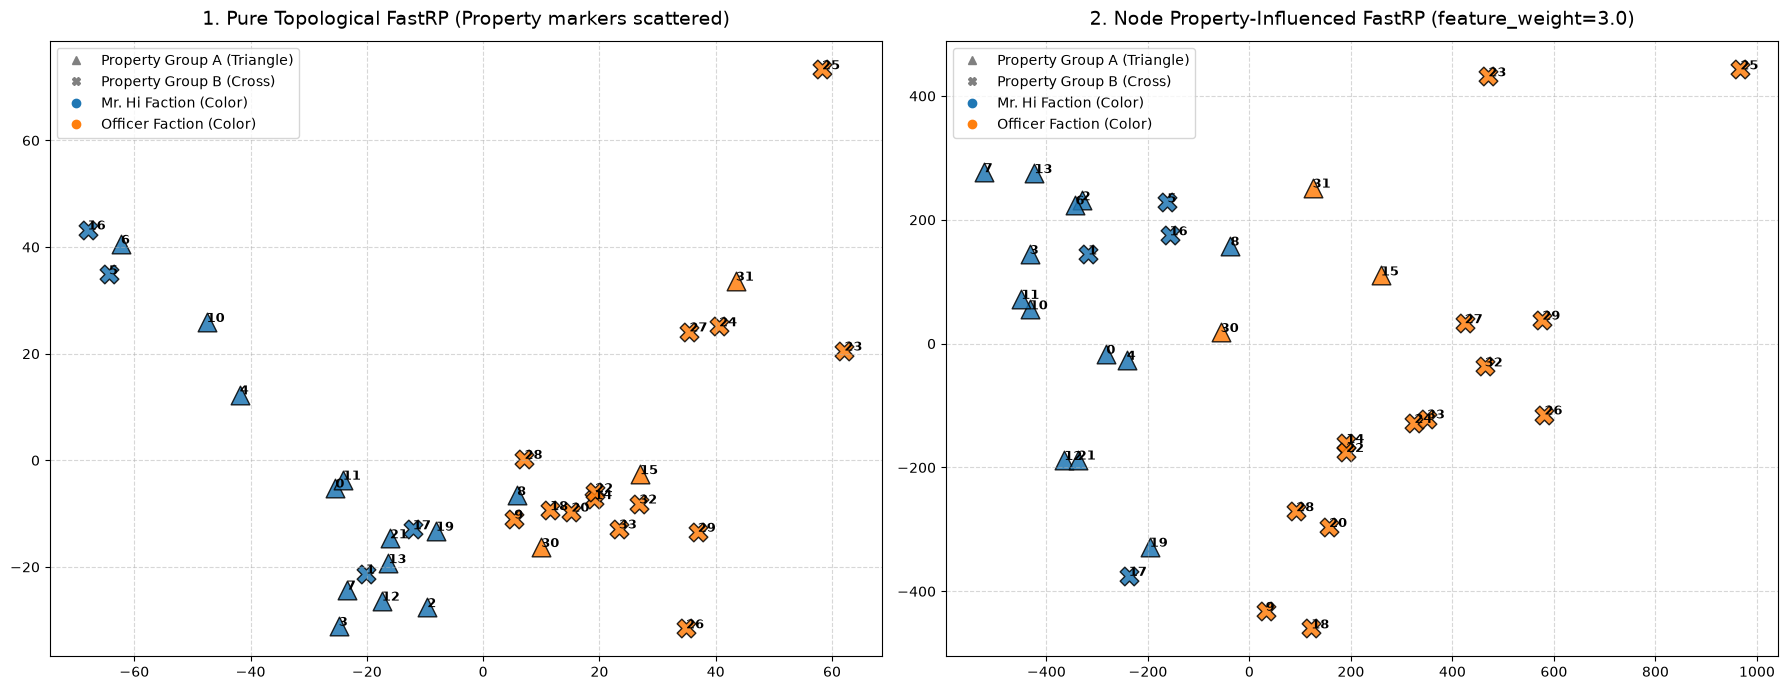

In [18]:
# Comparative Plot: Pure Topology vs. Node Property-Influenced FastRP
try:
    pca = PCA(n_components=2)
    emb_2d_base = pca.fit_transform(embeddings_dense)
    emb_2d_feat = pca.fit_transform(embeddings_feat)

    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    colors = ["#1f77b4" if G.nodes[node]["club"] == "Mr. Hi" else "#ff7f0e" for node in G.nodes()]

    # Plot 1: Pure Topology FastRP (Property markers scattered according to topology alone)
    for i in range(n_nodes):
        marker = "^" if property_groups[i] == 0 else "X"
        axes[0].scatter(emb_2d_base[i, 0], emb_2d_base[i, 1], c=colors[i], marker=marker, s=180, edgecolors="black", alpha=0.85)
        axes[0].text(emb_2d_base[i, 0] + 0.02, emb_2d_base[i, 1] + 0.02, str(i), fontsize=9, weight="bold")
    
    axes[0].plot([], [], "^", color="gray", label="Property Group A (Triangle)")
    axes[0].plot([], [], "X", color="gray", label="Property Group B (Cross)")
    axes[0].plot([], [], "o", color="#1f77b4", label="Mr. Hi Faction (Color)")
    axes[0].plot([], [], "o", color="#ff7f0e", label="Officer Faction (Color)")
    axes[0].set_title("1. Pure Topological FastRP (Property markers scattered)", fontsize=14, pad=12)
    axes[0].grid(True, linestyle="--", alpha=0.5)
    axes[0].legend(fontsize=10)

    # Plot 2: Property-Influenced FastRP (Node features pull property markers together)
    for i in range(n_nodes):
        marker = "^" if property_groups[i] == 0 else "X"
        axes[1].scatter(emb_2d_feat[i, 0], emb_2d_feat[i, 1], c=colors[i], marker=marker, s=180, edgecolors="black", alpha=0.85)
        axes[1].text(emb_2d_feat[i, 0] + 0.02, emb_2d_feat[i, 1] + 0.02, str(i), fontsize=9, weight="bold")
    
    axes[1].plot([], [], "^", color="gray", label="Property Group A (Triangle)")
    axes[1].plot([], [], "X", color="gray", label="Property Group B (Cross)")
    axes[1].plot([], [], "o", color="#1f77b4", label="Mr. Hi Faction (Color)")
    axes[1].plot([], [], "o", color="#ff7f0e", label="Officer Faction (Color)")
    axes[1].set_title("2. Node Property-Influenced FastRP (feature_weight=3.0)", fontsize=14, pad=12)
    axes[1].grid(True, linestyle="--", alpha=0.5)
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()
except ImportError:
    print("Please install scikit-learn and matplotlib to view the visual embeddings comparison plot.")